# 06 — Bayesian regime switching: do weather-driven regimes explain the spread?

A structural alternative to the black-box classifier of notebook 04. The hypothesis: the corn–soybean spread
reverts to *different* equilibria depending on the growing conditions (e.g. corn-stressed vs soy-stressed years), and
weather shifts the probability of being in each regime. If the regimes were identifiable, the regime probability
would tell us which equilibrium the spread is currently reverting to.

**Model** (`src/regime.py`)
$$y_t = (1-\phi)\,\mu_{s_t} + \phi\, y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim N(0,\sigma^2), \qquad \mu_0 < \mu_1$$
$$z_t = \alpha_0 + w_t'\alpha + h_t'\kappa + \delta\, s_{t-1} + \eta_t, \qquad \eta_t \sim N(0,1), \qquad s_t = \mathbb{1}[z_t > 0]$$

$y_t$ is the Kalman-filtered spread, $w_t$ standardised weather variables, $h_t$ Fourier seasonal terms (so that
weather is not credited with pure seasonality) and $\delta > 0$ makes regimes persistent. With conjugate priors the
Gibbs sampler draws the state path by forward-filtering backward-sampling, the probit utilities by Albert–Chib, and
$(\gamma, \mu, \phi, \sigma^2)$ from their conditional posteriors.

**Result in one line:** the sampler does not converge, and the two checks at the end show why — the regime means are
not identified when the spread is this persistent, and the bimodality that motivated the model is what a
single-regime AR(1) produces anyway.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from sklearn.mixture import GaussianMixture
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from src.data import load_full_dataset, save_figure, save_table
from src.features import compute_kalman_hedge
from src.regime import (prepare_regime_data, gibbs_regime_switching, posterior_summary, hpdi,
                        simulate_regime_switching, fixed_state_sampler)

df = load_full_dataset(['corn', 'soybean'])
df = compute_kalman_hedge(df, 'close_corn', 'close_soybean', delta=1e-5)
spread = df['kf_spread']

Kalman (delta=1e-05): converged in 8 iterations, phi=0.99601 (half-life 173 days), gamma 0.255 to 0.735, innovation-z std 1.111 (ideal 1)


## 1. Motivation: is the spread bimodal?

A two-component Gaussian mixture fits the marginal distribution of the spread much better than one component
(lower BIC), which suggested two regimes with different means.

AR(1) fit of the spread: phi = 0.9959, sigma = 0.153
BIC gain of a 2-component mixture on the spread: 371


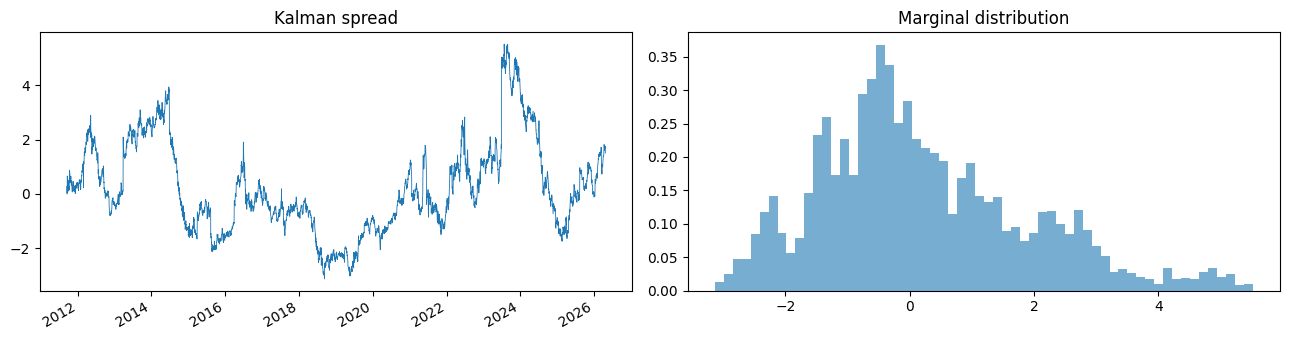

In [2]:
def gmm_bic_gain(x):
    """BIC(1 component) - BIC(2 components); positive = two components preferred."""
    x = np.asarray(x).reshape(-1, 1)
    bic1 = GaussianMixture(1, random_state=0).fit(x).bic(x)
    bic2 = GaussianMixture(2, random_state=0, n_init=5).fit(x).bic(x)
    return bic1 - bic2

ar1 = sm.OLS(spread.values[1:], sm.add_constant(spread.values[:-1])).fit()
PHI_HAT, SIGMA_HAT = ar1.params[1], np.sqrt(ar1.scale)
BIC_GAIN = gmm_bic_gain(spread)
print(f'AR(1) fit of the spread: phi = {PHI_HAT:.4f}, sigma = {SIGMA_HAT:.3f}')
print(f'BIC gain of a 2-component mixture on the spread: {BIC_GAIN:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
spread.plot(ax=axes[0], lw=0.6); axes[0].set_title('Kalman spread'); axes[0].set_xlabel('')
axes[1].hist(spread, bins=60, density=True, alpha=0.6); axes[1].set_title('Marginal distribution')
plt.tight_layout(); plt.show()

## 2. The sampler

Seven weather variables (soil moisture and heat in Mato Grosso and Iowa, Indiana precipitation, wind, humidity)
plus two Fourier harmonics enter the state equation. Weather coefficients get a tighter N(0, 0.5²) prior because the
probit is prone to near-separation. 5,000 burn-in + 5,000 kept draws.

In [3]:
WEATHER = [
    'soil_moisture_0_to_100cm_mean_mato_grosso_roll30d_min',
    'soil_moisture_28_to_100cm_mean_central_iowa_roll30d_min',
    'precipitation_sum_central_indiana_roll30d_sum',
    'temperature_2m_max_mato_grosso_roll30d_mean',
    'wind_speed_10m_max_central_iowa_roll30d_max',
    'relative_humidity_2m_mean_central_iowa_roll30d_mean',
    'wind_speed_10m_max_parana_roll30d_max',
]
y, y_lag, W, dates, state_names = prepare_regime_data(df, 'kf_spread', WEATHER, n_harmonics=2)

k = W.shape[1] + 2
G0 = np.eye(k)
G0[0, 0] = 4.0                                              # intercept
for j, name in enumerate(state_names, start=1):
    G0[j, j] = 1.0 if name.startswith('season_') else 0.25  # seasonal vs weather coefficients
G0[-1, -1] = 2.0                                            # persistence delta

draws = gibbs_regime_switching(y, y_lag, W, nos=5000, nob=5000, G0=G0, d0=np.var(y), seed=42)

  iteration 2,000 / 10,000


  iteration 4,000 / 10,000


  iteration 6,000 / 10,000


  iteration 8,000 / 10,000


  iteration 10,000 / 10,000


In [4]:
summary = posterior_summary(draws, state_names)
save_table(summary, '06_regime_posterior')
summary.round(4)

,mean,std,hpd 2.5%,hpd 97.5%,geweke z,geweke p
parameter,,,,,,
mu0,-3.7647,2.9145,-9.7889,0.8893,-5.5790,0.0000
mu1,1.7898,1.5412,-0.9421,4.9932,-19.4183,0.0000
phi,0.9963,0.0016,0.9934,0.9994,-0.0882,0.9297
sigma2,0.0242,0.0006,0.0231,0.0253,2.5491,0.0108
alpha0,0.7081,1.2215,-0.9815,3.0305,97.7590,0.0000
alpha: soil_moisture_0_to_100cm_mean_mato_grosso_roll30d_min,0.0359,0.3273,-0.6318,0.6366,-11.8920,0.0000
alpha: soil_moisture_28_to_100cm_mean_central_iowa_roll30d_min,-0.2773,0.3186,-0.8768,0.2560,-24.5768,0.0000
alpha: precipitation_sum_central_indiana_roll30d_sum,-0.0824,0.4117,-0.8676,0.7022,44.7600,0.0000
alpha: temperature_2m_max_mato_grosso_roll30d_mean,0.0704,0.4158,-0.7947,0.8232,39.0724,0.0000


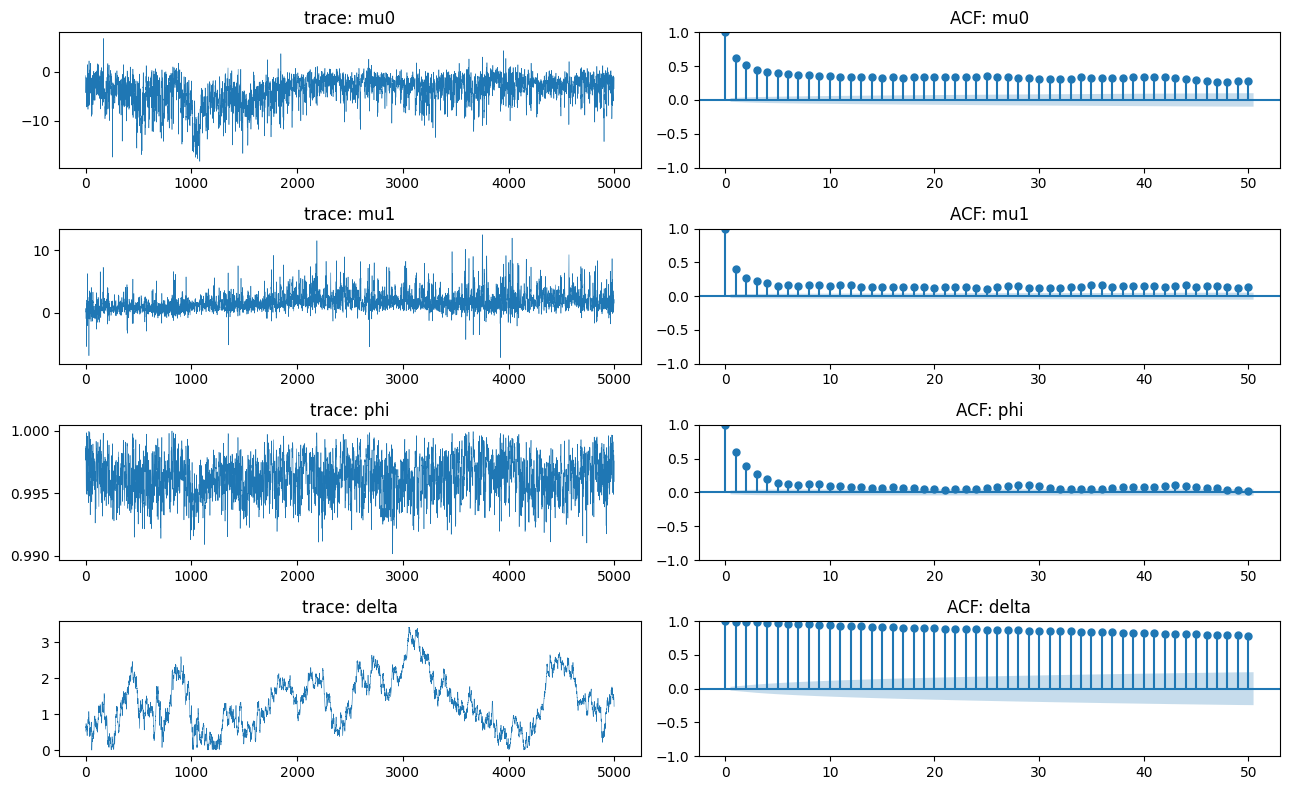

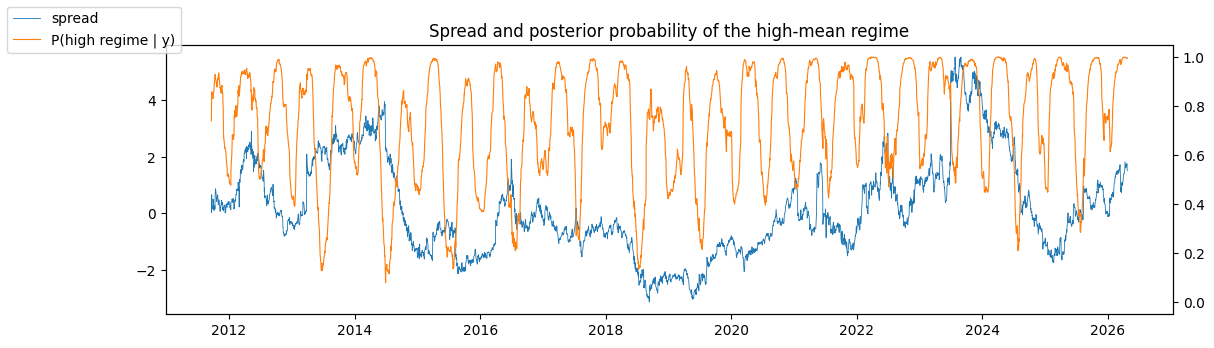

In [5]:
chains = {'mu0': draws['mu'][:, 0], 'mu1': draws['mu'][:, 1], 'phi': draws['phi'], 'delta': draws['gamma'][:, -1]}
fig, axes = plt.subplots(len(chains), 2, figsize=(13, 8))
for row, (name, chain) in zip(axes, chains.items()):
    row[0].plot(chain, lw=0.4); row[0].set_title(f'trace: {name}')
    plot_acf(chain, lags=50, ax=row[1], title=f'ACF: {name}')
plt.tight_layout(); plt.show()

fig, ax1 = plt.subplots(figsize=(13, 3.5))
ax1.plot(dates, y, lw=0.6, label='spread')
ax2 = ax1.twinx()
ax2.plot(dates, draws['state_prob'], color='C1', lw=0.8, label='P(high regime | y)')
ax2.set_ylim(-0.05, 1.05)
ax1.set_title('Spread and posterior probability of the high-mean regime')
fig.legend(loc='upper left'); plt.show()

The Geweke statistics are far outside ±2 for the regime means, the probit intercept and all state-equation
coefficients: the chains drift instead of mixing, so the posterior summaries cannot be interpreted. The regime means
have posterior standard deviations of 1.5–3 (comparable to the spread itself), and the regime probability simply
follows an annual cycle — the seasonal terms of the state equation, not the spread, decide the regime.

## 3. Why it fails (1): regime means are not identified at this persistence

In the observation equation the regime mean enters only through $(1-\phi)\mu_{s_t}$. With $\phi \approx 0.995$
that is a tiny fraction of the noise. We simulate data from the model with **known** regimes and sample
$(\mu, \phi, \sigma^2)$ holding the true state path fixed — the easiest possible case.

In [6]:
MU_TRUE, SIGMA2_TRUE, P_STAY, T_SIM = np.array([-1.0, 1.0]), 0.025, 0.95, 2000
rows, sims = [], {}
for phi_true in [0.5, 0.9, 0.99]:
    y_sim, s_sim = simulate_regime_switching(T_SIM + 1, phi_true, MU_TRUE, SIGMA2_TRUE, P_STAY,
                                             np.random.default_rng(42))
    out = fixed_state_sampler(y_sim[1:], y_sim[:-1], s_sim[1:], 3000, m_mu0=np.zeros(2), V_mu0=10 * np.eye(2),
                              m_phi0=0.0, V_phi0=1.0, nu0=1.0, d0=0.01, rng=np.random.default_rng(123))
    sims[phi_true] = {k: v[1000:] for k, v in out.items()}
    for j in (0, 1):
        chain = sims[phi_true]['mu'][:, j]
        lo, hi = hpdi(chain)
        rows.append({'phi': phi_true, 'parameter': f'mu{j}', 'true': MU_TRUE[j],
                     'posterior mean': chain.mean(), 'posterior std': chain.std(), 'HPD 2.5%': lo, 'HPD 97.5%': hi})
identification = pd.DataFrame(rows).set_index(['phi', 'parameter'])
save_table(identification, '06_regime_identification')
identification.round(3)

true  posterior mean  posterior std  HPD 2.5%  HPD 97.5%
phi  parameter                                                          
0.50 mu0        -1.0          -0.990          0.011    -1.014     -0.970
     mu1         1.0           1.003          0.009     0.985      1.021
0.90 mu0        -1.0          -0.947          0.062    -1.063     -0.818
     mu1         1.0           1.013          0.051     0.908      1.103
0.99 mu0        -1.0          -0.740          0.985    -2.728      0.672
     mu1         1.0           1.279          0.753     0.106      2.859

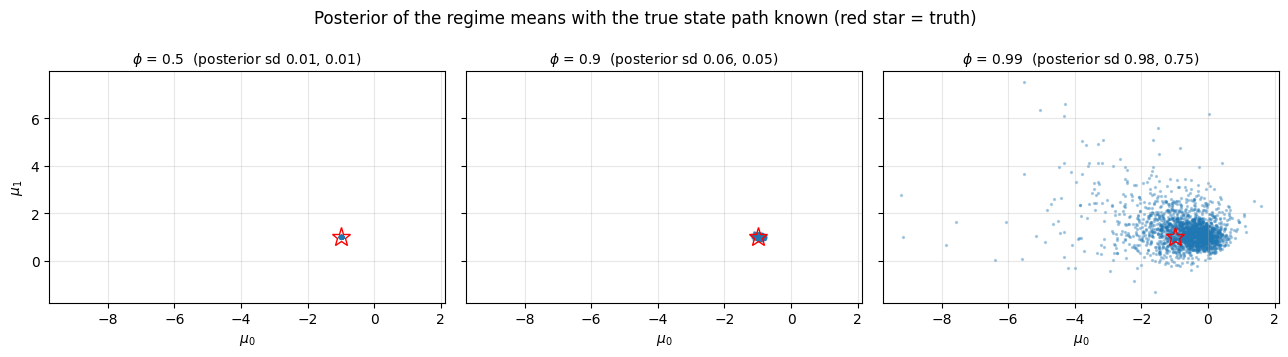

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True, sharey=True)
for ax, (phi_true, s) in zip(axes, sims.items()):
    ax.scatter(s['mu'][:, 0], s['mu'][:, 1], s=2, alpha=0.3)
    ax.plot(*MU_TRUE, marker='*', color='r', mfc='none', ms=14, lw=0)
    sd = s['mu'].std(axis=0)
    ax.set_title(f'$\\phi$ = {phi_true}  (posterior sd {sd[0]:.2f}, {sd[1]:.2f})', fontsize=10)
    ax.set_xlabel('$\\mu_0$'); ax.grid(alpha=0.3)
axes[0].set_ylabel('$\\mu_1$')
fig.suptitle('Posterior of the regime means with the true state path known (red star = truth)')
plt.tight_layout()
save_figure(fig, 'regime_identification')
plt.show()

## 4. Why it fails (2): the bimodality is an artefact of persistence

Would a single-regime AR(1) with the same persistence and noise also look bimodal over a sample of this length?
We simulate 200 such paths and compute the same mixture BIC gain.

In [8]:
rng = np.random.default_rng(0)
null_gains = []
for _ in range(200):
    eps = rng.normal(0, SIGMA_HAT, len(spread))
    eps[0] = rng.normal(0, SIGMA_HAT / np.sqrt(1 - PHI_HAT ** 2))    # stationary start
    null_gains.append(gmm_bic_gain(lfilter([1.0], [1.0, -PHI_HAT], eps)))
null_gains = np.array(null_gains)
print(f'Share of single-regime AR(1) paths where 2 components are preferred: {(null_gains > 0).mean():.0%}')
print(f'Real-data BIC gain {BIC_GAIN:.0f} is at the {(null_gains < BIC_GAIN).mean():.0%} percentile of the null')

Share of single-regime AR(1) paths where 2 components are preferred: 87%
Real-data BIC gain 371 is at the 87% percentile of the null


## 5. Does weather explain the spread beyond its own persistence?

Incremental $R^2$ and joint F-test of the (standardised) weather variables in an AR(1) for the level and in the
error-correction form $\Delta y_t$.

In [9]:
W_weather = W[:, :len(WEATHER)]
rows = {}
for name, target in [('level y_t', y), ('change dy_t', y - y_lag)]:
    base = sm.OLS(target, sm.add_constant(y_lag)).fit()
    full = sm.OLS(target, sm.add_constant(np.column_stack([y_lag, W_weather]))).fit()
    R = np.zeros((len(WEATHER), full.params.size)); R[:, 2:] = np.eye(len(WEATHER))
    f = full.f_test(R)
    rows[name] = {'R2 AR(1)': base.rsquared, 'R2 + weather': full.rsquared,
                  'incremental R2': full.rsquared - base.rsquared,
                  'F': float(np.squeeze(f.fvalue)), 'p-value': float(f.pvalue)}
pd.DataFrame(rows).T.round(4)

,R2 AR(1),R2 + weather,incremental R2,F,p-value
level y_t,0.9917,0.9917,0.0000,1.9285,0.0612
change dy_t,0.0020,0.0057,0.0037,1.9285,0.0612


**Take-aways.**
* With $\phi$ close to 1 the regime means are not identified from data of realistic length: the posterior of
  $(\mu_0, \mu_1)$ widens from a tight cloud at $\phi = 0.5$ to a long ridge at $\phi = 0.99$, even when the true
  regimes are known.
* The bimodal look of the spread is what a single persistent AR(1) typically produces over ~15 years: most simulated
  single-regime paths also prefer two mixture components, and the real data is not unusual under that null.
* Weather adds almost nothing: the incremental $R^2$ for daily spread changes is below 1% and the weather variables
  are jointly insignificant at 5%.

We therefore did not build a trading strategy on this model.